In [1]:
# import core packages
import pandas as pd 
import numpy as np
import os
import snowflake.connector as snow
import pyreadstat
import xlsxwriter
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import NamedStyle

# see all columns
pd.set_option('display.max_columns', None)

# define enviro variables
user = os.environ['USER']
username = os.environ["SNOWFLAKE_USER"]
sf_pass = os.environ["SNOWFLAKE_PASSWORD"]

# set working directory
os.chdir(f"/Users/{user}/Library/CloudStorage/GoogleDrive-{user}@opportunityatwork.org/Shared drives/Insights")
# see all columns
pd.set_option('display.max_columns', None)

# establish snowflake connection
conn = snow.connect(
    user=username,
    password=sf_pass,
    account='avb99459.us-east-1',
    warehouse='OPPORTUNITYATWORK_WH',
    role='PUBLIC'
)

cur = conn.cursor()

In [ ]:
#where ps.skill_type = 'Specialized Skill'
#      and (
#          ps.skill_name ILIKE 'Machine Learning' or
#          ps.skill_name ILIKE 'Artificial Intelligence' or
#          ps.skill_name ILIKE 'Natural Language Processing' or
#          ps.skill_name ILIKE 'Deep Learning' or
#          ps.skill_name ILIKE 'Generative AI' or
#         ps.skill_name ILIKE 'Large Language Models' or
#          ps.skill_name ILIKE 'TensorFlow' or
#          ps.skill_name ILIKE 'PyTorch' or
#          ps.skill_name ILIKE 'ChatGPT' or
#          ps.skill_name ILIKE 'Computer Vision'
#      )
#      and year(p.posted) = 2024

### share of entry level positions in AI exposed occs vs Non-AI exposed occs

In [ ]:
#calc of ai exposed
#median of ai-exposed -> actor was getting flagged as ai-exposed when used median
#

In [2]:
ai_skills = [
    'ethical AI', 'data sovereignty', 'AI security', 'artificial intelligence risk',
    'agentic systems', 'AI/ML inference', 'AIOps', 'AI personalization', 'AI testing',
    'applications of artificial intelligence', 'artificial general intelligence', 'artificial intelligence',
    'artificial intelligence development', 'Artificial Intelligence Markup Language', 'artificial intelligence systems',
    'automated data cleaning', 'Azure Cognitive Services', 'Baidu', 'cognitive automation',
    'cognitive computing', 'computational intelligence', 'Cortana', 'Data Version Control', 'Edge Intelligence',
    'embedded AI', 'expert systems', 'explainable AI', 'intelligent control', 'intelligent systems',
    'interactive kiosk', 'IPSoft Amelia', 'knowledge distillation', 'knowledge engineering',
    'knowledge-based configuration', 'knowledge-based systems', 'knowledge representation', 'multi-agent systems',
    'neuro-symbolic AI', 'Open Neural Network Exchange', 'OpenAI Gym', 'operationalizing AI', 'PineCone', 'Qdrant',
    'reasoning systems', 'swarm intelligence', 'synthetic data generation', 'Watson Conversation', 'Watson Studio',
    'Weka', 'Weaviate', 'advanced driver-assistance systems', 'autonomous cruise control systems',
    'autonomous system', 'autonomous vehicles', 'dynamic routing', 'guidance navigation and control systems',
    'light detection and ranging', 'object tracking', 'OpenCV', 'path analysis', 'path finding', 'remote sensing',
    'scene understanding', 'unmanned aerial systems', 'Adobe Sensei', 'ChatGPT', 'CrewAI', 'DALL-E image generator',
    'generative adversarial networks', 'generative AI agents', 'generative artificial intelligence',
    'Google Bard', 'image inpainting', 'image super-resolution', 'LangGraph', 'large language modeling',
    'Microsoft Copilot', 'multimodal learning', 'multimodal models', 'prompt engineering',
    'retrieval-augmented generation', 'Stable Diffusion', 'text summarization', 'text to speech',
    'variational autoencoders', 'AdaBoost', 'adversarial machine learning', 'Apache MADlib', 'Apache Mahout',
    'Apache SINGA', 'Apache Spark', 'association rule learning', 'attention mechanisms', 'AutoGen',
    'automated machine learning', 'autonomic computing', 'AWS SageMaker', 'Azure Machine Learning',
    'bagging techniques', 'Bayesian belief networks', 'Boltzmann Machine', 'boosting',
    'Chi-Squared Automatic Interaction Detection', 'Classification and Regression Tree', 'cluster analysis',
    'collaborative filtering', 'concept drift detection', 'confusion matrix', 'cyber-physical systems', 'Dask',
    'data classification', 'Dbscan', 'decision models', 'decision-tree learning', 'dimensionality reduction',
    'distributed machine learning', 'Dlib', 'embedded intelligence', 'ensemble methods', 'evolutionary programming',
    'expectation maximization algorithm', 'feature engineering', 'feature extraction', 'feature learning',
    'feature selection', 'federated learning', 'game AI', 'Gaussian process', 'genetic algorithm', 'Google AutoML',
    'Google Cloud ML Engine', 'gradient boosting', 'gradient boosting machines', 'H2O.ai', 'hidden Markov model',
    'hyperparameter optimization', 'incremental learning', 'inference engine', 'k-means clustering', 'kernel methods',
    'Kubeflow', 'LIBSVM', 'loss functions', 'machine learning', 'machine learning algorithms',
    'machine learning methods', 'machine learning model monitoring and evaluation', 'machine learning model training',
    'Markov chain', 'matrix factorization', 'meta learning', 'Microsoft Cognitive Toolkit', 'MLflow', 'MLOps',
    'mlpack', 'ModelOps', 'Naive Bayes Classifier', 'neural architecture compression', 'neural architecture search',
    'objective function', 'Oracle Autonomous Database', 'Perceptron', 'Predictionio', 'predictive modeling',
    'programmatic media buying', 'Pydata', 'PyTorch', 'PyTorch Lightning', 'Random Forest Algorithm',
    'recommender systems', 'reinforcement learning', 'Scikit-Learn', 'semi-supervised learning', 'soft computing',
    'sorting algorithm', 'supervised learning', 'support vector machines', 't-SNE', 'test datasets',
    'topological data analysis', 'Torch', 'training datasets', 'transfer learning', 'transformer',
    'unsupervised learning', 'Vowpal Wabbit', 'Xgboost', 'Theano', 'AI copywriting', 'Amazon Alexa', 'Amazon Textract',
    'ANTLR', 'Apache OpenNLP', 'BERT', 'chatbot', 'computational linguistics', 'conversational AI', 'DeepSpeech',
    'dialog systems', 'fastText', 'fuzzy logic', 'handwriting recognition', 'Hugging Face', 'Hugging Face Transformers',
    'intelligent agent', 'intelligent virtual assistant', 'Kaldi', 'language model', 'latent Dirichlet allocation',
    'Lexalytics', 'machine translation', 'Microsoft LUIS', 'natural language generation', 'natural language processing',
    'natural language programming', 'natural language toolkits', 'natural language understanding',
    'natural language user interface', 'nearest neighbour algorithm', 'Nuance Mix', 'optical character recognition',
    'screen reader', 'semantic analysis', 'semantic interpretation for speech recognition', 'semantic kernel',
    'semantic parsing', 'semantic search', 'sentence transformers', 'sentiment analysis', 'Seq2Seq', 'Shogun',
    'small language model', 'speech recognition', 'speech recognition software', 'speech synthesis',
    'statistical language acquisition', 'summarization methods', 'text mining', 'text retrieval systems',
    'text to speech', 'tokenization', 'Vespa', 'voice assistant technology', 'voice interaction',
    'voice user interface', 'word embedding', 'Word2Vec models', 'Apache MXNet', 'artificial neural networks',
    'autoencoders', 'Caffe', 'Caffe2', 'Chainer', 'convolutional neural networks', 'Cudnn', 'deep learning',
    'deep learning methods', 'Deeplearning4j', 'deep reinforcement learning', 'evolutionary acquisition of neural topologies',
    'Fast.AI', 'graph neural networks', 'Keras', 'Long Short-Term Memory', 'neural ordinary differential equations',
    'OpenVINO', 'PaddlePaddle', 'Pybrain', 'recurrent neural network', 'reinforcement learning',
    'residual networks', 'sequence-to-sequence models', 'spiking neural networks', 'TensorFlow',
    'advanced robotics', 'bot framework', 'cognitive robotics', 'meta-reinforcement learning',
    'motion planning', 'Nvidia Jetson', 'OpenAI Gym environments', 'reinforcement learning from human feedback',
    'robot framework', 'robot operating systems', 'robotic automation software', 'robotic liquid handling systems',
    'robotic programming', 'robotic systems', 'servomotor', 'SLAM algorithms', '3D reconstruction',
    'activity recognition', 'computer vision', 'contextual image classification', 'Deck.gl', 'digital image processing',
    'digital twin technology', 'eye tracking', 'face detection', 'facial recognition',
    'general-purpose computing on graphics processing units', 'gesture recognition', 'image analysis',
    'image captioning', 'image matching', 'image recognition', 'image segmentation', 'image sensor',
    'ImageNet', 'instance segmentation', 'machine vision', 'MNIST', 'motion analysis', 'object recognition',
    'OmniPage', 'pose estimation', 'RealSense', 'thermal imaging analysis'
]


In [3]:
skill_conditions = " OR\n          ".join(
    [f"ps.skill_name ILIKE '%{skill}%'" for skill in ai_skills]
)


In [ ]:
query = f"""
with total_postings as (
    select 
        soc_2021_5_name, 
        count(distinct id) as total_postings
    from emsi.us.postings
    where year(posted) between 2014 and 2024
    group by soc_2021_5_name
),

ai_postings as (
    select 
        p.soc_2021_5_name, 
        count(distinct p.id) as ai_postings
    from emsi.us.postings p
    join emsi.us.postings_skills ps on ps.id = p.id
    where ps.skill_type = 'Specialized Skill'
      and (
          {skill_conditions}
      )
      and year(p.posted) between 2014 and 2024
    group by p.soc_2021_5_name
),

ai_exposure as (
    select 
        tp.soc_2021_5_name,
        tp.total_postings,
        ap.ai_postings,
        round(100.0 * coalesce(ap.ai_postings, 0)::numeric / nullif(tp.total_postings, 0), 2) as ai_exposure_pct
    from total_postings tp
    left join ai_postings ap 
        on tp.soc_2021_5_name = ap.soc_2021_5_name
),

growth as (
    select 
        soc_2021_5_name,
        sum(case when year(posted) = 2014 then 1 else 0 end) as postings_2014,
        sum(case when year(posted) = 2024 then 1 else 0 end) as postings_2024
    from emsi.us.postings
    where year(posted) in (2014, 2024)
    group by soc_2021_5_name
)

select 
    ae.soc_2021_5_name,
    g.postings_2014,
    g.postings_2024,
    round(100.0 * (g.postings_2024 - g.postings_2014) / nullif(g.postings_2014, 0), 2) as posting_growth_pct,
    ae.ai_postings,
    ae.total_postings,
    ae.ai_exposure_pct
from ai_exposure ae
join growth g on ae.soc_2021_5_name = g.soc_2021_5_name
where g.postings_2014 >= 1000 and g.postings_2024 >= 1000 and ae.ai_postings is not null
order by ai_exposure_pct desc
"""
cur = conn.cursor().execute(query)
df3 = pd.DataFrame.from_records(iter(cur), 
                               columns=[x[0] for x in cur.description])

df3.columns = df3.columns.str.lower()


In [ ]:
df3.head(60)

,soc_2021_5_name,postings_2014,postings_2024,posting_growth_pct,ai_postings,total_postings,ai_exposure_pct
0,Computer and Information Research Scientists,8474,55603,556.16,198355,352418,56.28
1,Electrical Power-Line Installers and Repairers,5947,12783,114.95,46595,117573,39.63
2,Electro-Mechanical and Mechatronics Technologi...,1093,3114,184.90,5522,24196,22.82
3,Data Scientists,185378,231190,24.71,554845,2885285,19.23
4,"Engineers, All Other",12820,18992,48.14,35499,205208,17.30
5,Statisticians,13233,9541,-27.90,27453,164250,16.71
6,"Electrical and Electronics Repairers, Powerhou...",7110,10260,44.30,17711,106832,16.58
7,Electricians,49366,75457,52.85,127700,774627,16.49
8,Database Architects,83347,81099,-2.70,158732,1092974,14.52
9,Database Administrators,99683,87309,-12.41,184362,1319429,13.97


In [2]:
query = f'''
with total_postings as (
    select 
        soc_2021_5_name, 
        count(distinct id) as total_postings
    from emsi.us.postings
    where year(posted) between 2014 and 2024
    group by soc_2021_5_name
),

ai_postings as (
    select 
        p.soc_2021_5_name, 
        count(distinct p.id) as ai_postings
    from emsi.us.postings p
    join emsi.us.postings_skills ps on ps.id = p.id
    where ps.skill_type = 'Specialized Skill'
      and (
          ps.skill_name ILIKE 'Machine Learning' OR
          ps.skill_name ILIKE 'Artificial Intelligence' OR
          ps.skill_name ILIKE 'Computer Science' OR
          ps.skill_name ILIKE 'Data Science' OR
          ps.skill_name ILIKE 'Software Engineering' OR
          ps.skill_name ILIKE 'Software Development' OR
          ps.skill_name ILIKE 'Algorithms' OR
          ps.skill_name ILIKE 'Generative Artificial Intelligence' OR
          ps.skill_name ILIKE 'Apache Spark' OR
          ps.skill_name ILIKE 'Java (Programming Language)' OR
          ps.skill_name ILIKE 'Big Data' OR
          ps.skill_name ILIKE 'Data Engineering' OR
          ps.skill_name ILIKE 'C++ (Programming Language)' OR
          --ps.skill_name ILIKE 'Programming Languages' OR
          --ps.skill_name ILIKE 'Data Modeling' OR
          ps.skill_name ILIKE 'Data Management' OR
          ps.skill_name ILIKE 'Predictive Modeling' OR
          ps.skill_name ILIKE 'Extract Transform Load (ETL)' OR
          ps.skill_name ILIKE 'DevOps' OR
          ps.skill_name ILIKE 'Deep Learning' OR
          ps.skill_name ILIKE 'JavaScript (Programming Language)' OR
          ps.skill_name ILIKE 'Data Pipelines' OR
          ps.skill_name ILIKE 'Kubernetes' OR
          ps.skill_name ILIKE 'Data Warehousing'   
      )
      and year(p.posted) between 2014 and 2024
    group by p.soc_2021_5_name
),

ai_exposure as (
    select 
        tp.soc_2021_5_name,
        tp.total_postings,
        ap.ai_postings,
        round(100.0 * coalesce(ap.ai_postings, 0)::numeric / nullif(tp.total_postings, 0), 2) as ai_exposure_pct
    from total_postings tp
    left join ai_postings ap 
        on tp.soc_2021_5_name = ap.soc_2021_5_name
),

growth as (
    select 
        soc_2021_5_name,
        sum(case when year(posted) = 2014 then 1 else 0 end) as postings_2014,
        sum(case when year(posted) = 2024 then 1 else 0 end) as postings_2024
    from emsi.us.postings
    where year(posted) in (2014, 2024)
    group by soc_2021_5_name
)

select 
    ae.soc_2021_5_name,
    g.postings_2014,
    g.postings_2024,
    round(100.0 * (g.postings_2024 - g.postings_2014) / nullif(g.postings_2014, 0), 2) as posting_growth_pct,
    ae.ai_postings,
    ae.total_postings,
    ae.ai_exposure_pct
from ai_exposure ae
join growth g on ae.soc_2021_5_name = g.soc_2021_5_name
where g.postings_2014 >= 1000 and g.postings_2024 >= 1000 and ae.ai_postings is not null
order by ai_exposure_pct desc

'''

cur = conn.cursor().execute(query)
df3 = pd.DataFrame.from_records(iter(cur), 
                               columns=[x[0] for x in cur.description])

df3.columns = df3.columns.str.lower()

In [3]:
df3.head(50)

,soc_2021_5_name,postings_2014,postings_2024,posting_growth_pct,ai_postings,total_postings,ai_exposure_pct
0,Computer and Information Research Scientists,8474,53328,529.31,320983,350181,91.66
1,Web Developers,119061,44000,-63.04,1084821,1296548,83.67
2,Software Developers,615673,525272,-14.68,7387509,9460700,78.09
3,Database Administrators,99666,84389,-15.33,847500,1316728,64.36
4,Software Quality Assurance Analysts and Testers,86415,54857,-36.52,644706,1060584,60.79
5,Database Architects,83330,78191,-6.17,642560,1090024,58.95
6,Computer Programmers,46663,20328,-56.44,240478,421392,57.07
7,Data Scientists,185377,222932,20.26,1528607,2877294,53.13
8,"Computer Occupations, All Other",312082,401785,28.74,2513854,5259991,47.79
9,Web and Digital Interface Designers,81558,56434,-30.81,498816,1089636,45.78


Summary stats for AI exposure:
        ai_postings  total_postings
count  6.060000e+02    6.060000e+02
mean   4.416902e+04    6.087104e+05
std    3.359161e+05    1.368230e+06
min    2.000000e+00    9.066000e+03
25%    2.602500e+02    7.146500e+04
50%    1.438000e+03    1.639920e+05
75%    6.648250e+03    5.597812e+05
max    7.387509e+06    1.974855e+07


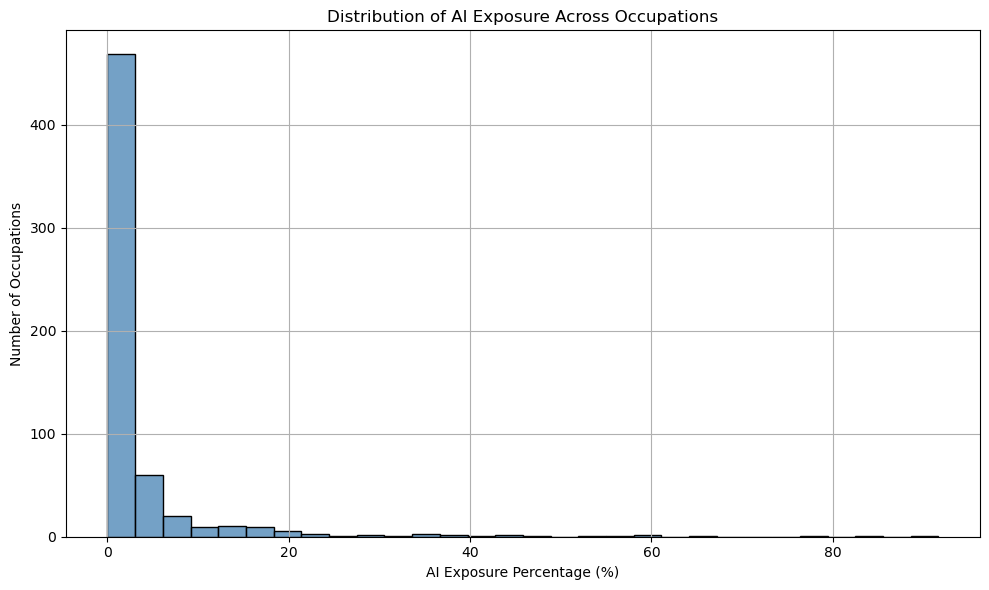


Summary stats by AI exposure group:


KeyError: 'ai_exposed'

In [5]:
# Summary statistics for AI exposure
print("Summary stats for AI exposure:")
print(df3[['ai_exposure_pct', 'ai_postings', 'total_postings']].describe())

# Histogram of AI exposure (you already have this part)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df3['ai_exposure_pct'], bins=30, color='steelblue')
plt.title('Distribution of AI Exposure Across Occupations')
plt.xlabel('AI Exposure Percentage (%)')
plt.ylabel('Number of Occupations')
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary stats split by binary AI exposure
print("\nSummary stats by AI exposure group:")
print(df3.groupby('ai_exposed')[['ai_exposure_pct', 'ai_postings', 'total_postings']].describe())

In [219]:
#df3.to_excel("/Users/khaliun/Downloads/ai_exposed_occs.xlsx", index=False)

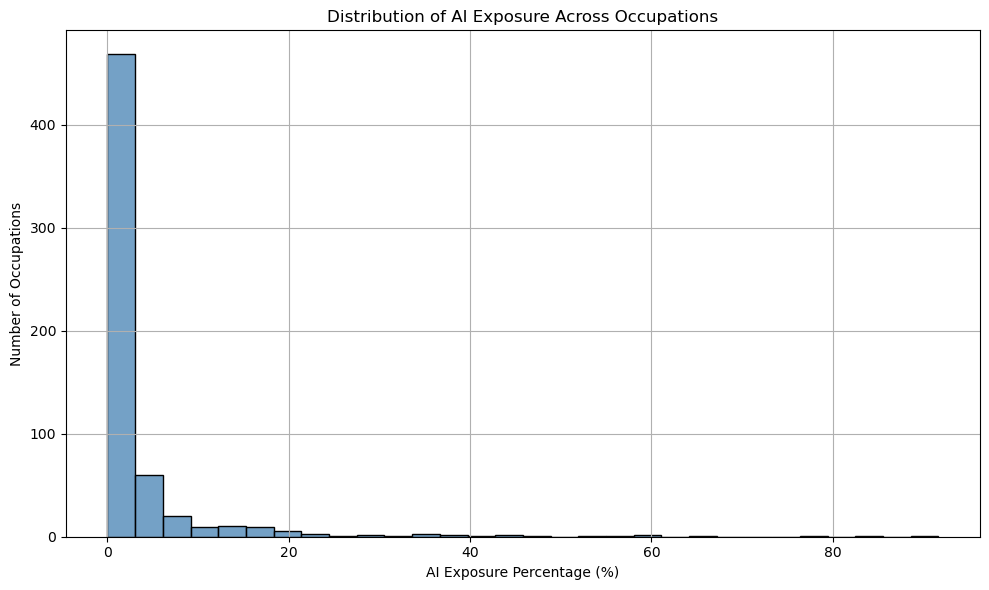

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make sure it's a numeric column
df3['ai_exposure_pct'] = pd.to_numeric(df3['ai_exposure_pct'], errors='coerce')

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(data=df3, x='ai_exposure_pct', bins=30, kde=False, color='steelblue')

# Formatting
plt.title('Distribution of AI Exposure Across Occupations')
plt.xlabel('AI Exposure Percentage (%)')
plt.ylabel('Number of Occupations')
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Step 1: Calculate the median AI exposure
median_exposure = df3['ai_exposure_pct'].median()

# Step 2: Create a new binary column 'ai_exposed'
df3['ai_exposed'] = (df3['ai_exposure_pct'] >= median_exposure).astype(int)

# Optional: Print the median and quick check
print(f"Median AI exposure: {median_exposure}")
df3[['soc_2021_5_name', 'ai_exposure_pct', 'ai_exposed']].head()


Median AI exposure: 0.67


,soc_2021_5_name,ai_exposure_pct,ai_exposed
0,Computer and Information Research Scientists,91.66,1
1,Web Developers,83.67,1
2,Software Developers,78.09,1
3,Database Administrators,64.36,1
4,Software Quality Assurance Analysts and Testers,60.79,1


In [9]:
# Calculate the 90th percentile (top 10%)
#threshold = df3['ai_exposure_pct'].quantile(0.9)
threshold = 4.8

# Create the binary 'ai_exposed' column: 1 if above threshold, else 0
df3['ai_exposed'] = (df3['ai_exposure_pct'] >= threshold).astype(int)

#print(f"Threshold for AI-exposed (80th percentile): {threshold:.2f}%")
print(df3[['soc_2021_5_name', 'ai_exposure_pct', 'ai_exposed']].head())


                                   soc_2021_5_name  ai_exposure_pct  \
0     Computer and Information Research Scientists            91.66   
1                                   Web Developers            83.67   
2                              Software Developers            78.09   
3                          Database Administrators            64.36   
4  Software Quality Assurance Analysts and Testers            60.79   

   ai_exposed  
0           1  
1           1  
2           1  
3           1  
4           1  


In [10]:
df3['ai_exposed'].value_counts()

ai_exposed
0    508
1     98
Name: count, dtype: int64

## Entry Level Jobs

In [11]:
query = f'''
WITH total_postings AS (
    SELECT 
        EXTRACT(YEAR FROM posted)::int AS year,
        soc_2021_5_name,
        COUNT(DISTINCT id) AS total_postings
    FROM emsi.us.postings
    WHERE year(posted) BETWEEN 2014 AND 2024
    GROUP BY year, soc_2021_5_name
),

entry_level_postings AS (
    SELECT 
        EXTRACT(YEAR FROM posted)::int AS year,
        soc_2021_5_name,
        COUNT(DISTINCT id) AS entry_level_postings
    FROM emsi.us.postings
    WHERE year(posted) BETWEEN 2014 AND 2024
      --AND (min_years_experience <= 1)
      AND (
          (job_seniority_name = 'Junior' AND min_years_experience IS NULL)
          OR min_years_experience <= 1
      )
      AND min_edulevels_name IN (
          'No Education Listed', 
          'High school or GED', 
          'Associate degree', 
          'Bachelor''s Degree'
      )
    GROUP BY year, soc_2021_5_name
),

entry_level_share AS (
    SELECT 
        tp.year,
        tp.soc_2021_5_name,
        tp.total_postings,
        elp.entry_level_postings,
        ROUND(100.0 * COALESCE(elp.entry_level_postings, 0)::numeric / NULLIF(tp.total_postings, 0), 2) AS entry_level_pct
    FROM total_postings tp
    LEFT JOIN entry_level_postings elp 
        ON tp.year = elp.year AND tp.soc_2021_5_name = elp.soc_2021_5_name
)

SELECT *
FROM entry_level_share
WHERE total_postings > 100
ORDER BY year, soc_2021_5_name, entry_level_pct
'''

cur = conn.cursor().execute(query)
yoe_time_series = pd.DataFrame.from_records(iter(cur), 
                               columns=[x[0] for x in cur.description])

yoe_time_series.columns = yoe_time_series.columns.str.lower()

#add min job_posting > 100

In [12]:
yoe_time_series.head(20)

,year,soc_2021_5_name,total_postings,entry_level_postings,entry_level_pct
0,2014,Accountants and Auditors,234928,10778.0,4.59
1,2014,Actors,5863,1076.0,18.35
2,2014,Actuaries,12001,530.0,4.42
3,2014,Acupuncturists,984,42.0,4.27
4,2014,Adhesive Bonding Machine Operators and Tenders,5005,633.0,12.65
5,2014,"Administrative Law Judges, Adjudicators, and H...",467,35.0,7.49
6,2014,Administrative Services Managers,27464,2075.0,7.56
7,2014,"Adult Basic Education, Adult Secondary Educati...",6316,422.0,6.68
8,2014,Advertising Sales Agents,69418,10873.0,15.66
9,2014,Advertising and Promotions Managers,5459,407.0,7.46


In [13]:
# Merge on soc_2021_5_name to combine entry-level data with AI exposure classification
merged = yoe_time_series.merge(
    df3[['soc_2021_5_name', 'ai_exposed']],
    on='soc_2021_5_name',
    how='left'
)

# Sanity check
merged.head()

,year,soc_2021_5_name,total_postings,entry_level_postings,entry_level_pct,ai_exposed
0,2014,Accountants and Auditors,234928,10778.0,4.59,0.0
1,2014,Actors,5863,1076.0,18.35,0.0
2,2014,Actuaries,12001,530.0,4.42,1.0
3,2014,Acupuncturists,984,42.0,4.27,NaN
4,2014,Adhesive Bonding Machine Operators and Tenders,5005,633.0,12.65,0.0


In [14]:
merged.groupby('year')['soc_2021_5_name'].nunique().reset_index(name='num_occupations')


,year,num_occupations
0,2014,699
1,2015,702
2,2016,698
3,2017,699
4,2018,712
5,2019,719
6,2020,713
7,2021,727
8,2022,726
9,2023,721


In [15]:
# Step 1: Count in how many years each occupation appears
occurrence_counts = merged.groupby('soc_2021_5_name')['year'].nunique()

# Step 2: Determine the total number of distinct years
total_years = merged['year'].nunique()

# Step 3: Filter for occupations that appear in all years
valid_occupations = occurrence_counts[occurrence_counts == total_years].index

# Step 4: Filter the original merged DataFrame
merged_filtered = merged[merged['soc_2021_5_name'].isin(valid_occupations)].copy()

# Make sure now all occupations are present in all years
merged_filtered.groupby('year')['soc_2021_5_name'].nunique()

year
2014    688
2015    688
2016    688
2017    688
2018    688
2019    688
2020    688
2021    688
2022    688
2023    688
2024    688
Name: soc_2021_5_name, dtype: int64

In [343]:
merged_filtered

,year,soc_2021_5_name,total_postings,entry_level_postings,entry_level_pct,ai_exposed
0,2014,Accountants and Auditors,235158,10743.0,4.57,0.0
1,2014,Actors,5866,991.0,16.89,0.0
2,2014,Actuaries,11948,529.0,4.43,1.0
3,2014,Acupuncturists,1004,42.0,4.18,0.0
4,2014,Adhesive Bonding Machine Operators and Tenders,5009,627.0,12.52,0.0
...,...,...,...,...,...,...
7834,2024,"Welding, Soldering, and Brazing Machine Setter...",4938,885.0,17.92,0.0
7835,2024,Wind Turbine Service Technicians,4674,911.0,19.49,0.0
7837,2024,Word Processors and Typists,7545,1049.0,13.90,0.0
7838,2024,Writers and Authors,31126,2243.0,7.21,0.0


In [16]:
merged_filtered['ai_exposed'].value_counts()

ai_exposed
0.0    5588
1.0    1078
Name: count, dtype: int64

In [17]:
#problem set 4
# -------------------------------
# STEP: Pre-treatment Summary Stats
# -------------------------------
pre_treatment = merged_filtered[merged_filtered['year'] < 2023]

# Calculate average entry-level share by AI exposure group
pre_treatment_summary = pre_treatment.groupby('ai_exposed')['entry_level_pct'].agg(['mean', 'std', 'count'])
print("\nPre-treatment entry-level share summary by AI exposure:")
print(pre_treatment_summary)



Pre-treatment entry-level share summary by AI exposure:
                 mean       std  count
ai_exposed                            
0.0         13.469014  8.201812   4572
1.0          6.439172  4.370775    882


In [18]:
temp = merged_filtered.assign(weighted_entry_level = merged_filtered['entry_level_pct'] * merged_filtered['total_postings'])

weighted_result = (
    temp
    .groupby(['year', 'ai_exposed'])
    .agg(
        weighted_sum = ('weighted_entry_level', 'sum'),
        total_postings_sum = ('total_postings', 'sum')
    )
    .reset_index()
)

weighted_result['weighted_entry_level_share'] = weighted_result['weighted_sum'] / weighted_result['total_postings_sum']
weighted_result = weighted_result.drop(columns=['weighted_sum', 'total_postings_sum'])
weighted_result



weighted_result['ai_exposed_label'] = weighted_result['ai_exposed'].map({0: 'Non-AI', 1: 'AI-exposed'})
weighted_result


,year,ai_exposed,weighted_entry_level_share,ai_exposed_label
0,2014,0.0,13.10980769825637119568074704,Non-AI
1,2014,1.0,5.260767938238478132524476243,AI-exposed
2,2015,0.0,14.05440747329619832920810271,Non-AI
3,2015,1.0,4.922735477806300686820404930,AI-exposed
4,2016,0.0,14.87298815448149956308669358,Non-AI
5,2016,1.0,5.259436977527887155045225977,AI-exposed
6,2017,0.0,15.25500120523464167949361388,Non-AI
7,2017,1.0,5.030537255220020984509220890,AI-exposed
8,2018,0.0,14.01365698512036993051472253,Non-AI
9,2018,1.0,5.265934162197661794648655819,AI-exposed


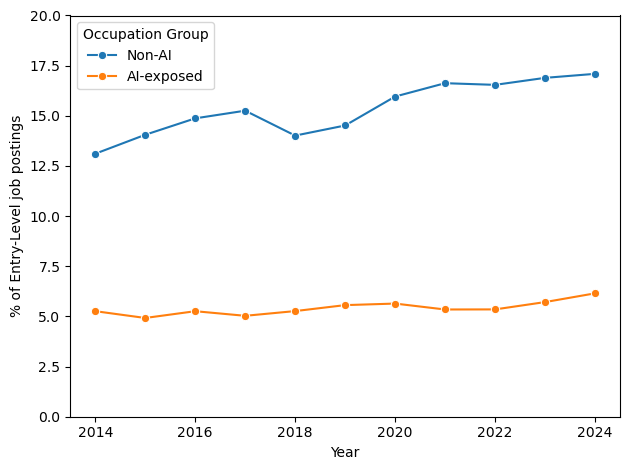

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=weighted_result,
    x='year',
    y='weighted_entry_level_share',
    hue='ai_exposed_label',
    marker='o'
)

#plt.title('Entry-Level Share Over Time by AI Exposure')
plt.ylabel('% of Entry-Level job postings')
plt.xlabel('Year')
plt.ylim(0, 20)  # Set y-axis max to 25%
#plt.ylim(0, 100)
plt.legend(title='Occupation Group')
plt.tight_layout()
plt.show()


In [21]:
from scipy.stats import ttest_ind

# Make sure both groups are numeric (float)
group0 = pre_treatment[pre_treatment['ai_exposed'] == 0]['entry_level_pct'].astype(float)
group1 = pre_treatment[pre_treatment['ai_exposed'] == 1]['entry_level_pct'].astype(float)

# Run t-test
t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
print(f"\nT-test for difference in pre-treatment entry-level share between AI-exposed and non-exposed:")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")




T-test for difference in pre-treatment entry-level share between AI-exposed and non-exposed:
t-statistic = 36.860, p-value = 0.000


In [22]:
# After: merged_filtered is created
# Insert here: Balance test

# Step 1: Restrict to pre-treatment
pre_treatment = merged_filtered[merged_filtered['year'] < 2023]

# Step 2: Summary stats by group
pre_treatment_summary = pre_treatment.groupby('ai_exposed')['entry_level_pct'].agg(['mean', 'std', 'count'])
print(pre_treatment_summary)

# Step 3: T-test
from scipy.stats import ttest_ind
group0 = pre_treatment[pre_treatment['ai_exposed'] == 0]['entry_level_pct'].astype(float)
group1 = pre_treatment[pre_treatment['ai_exposed'] == 1]['entry_level_pct'].astype(float)
t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
print(f"\nT-test for difference in pre-treatment entry-level share:")
print(f"t = {t_stat:.3f}, p = {p_val:.3f}")


                 mean       std  count
ai_exposed                            
0.0         13.469014  8.201812   4572
1.0          6.439172  4.370775    882

T-test for difference in pre-treatment entry-level share:
t = 36.860, p = 0.000
